<span style='color:#c21da9'> practicing a imputer techqunics in real world </span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\\Data Sets☠️💀\\indian_food.csv")

In [3]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [4]:
df.shape

(255, 9)

In [5]:
df.isna().sum()

name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            1
dtype: int64

In [6]:
def nan_values(s):
    for i in range(0,len(s),5):
        s.iloc[i] = np.nan
    return s # type: ignore

In [7]:
df[['diet','course','state','region','ingredients']]= nan_values(df[['diet','course','state','region','ingredients']])

C:\Users\91766\AppData\Local\Temp\ipykernel_21288\108850617.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s.iloc[i] = np.nan


In [8]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,NaN,NaN,45,25,sweet,NaN,NaN,NaN
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [9]:
df['state'].value_counts()

state
Gujarat            30
Punjab             28
Maharashtra        22
-1                 20
Tamil Nadu         18
West Bengal        18
Assam              15
Andhra Pradesh      9
Rajasthan           6
Odisha              6
Kerala              5
Uttar Pradesh       4
Goa                 3
Bihar               3
Telangana           3
Karnataka           3
Madhya Pradesh      2
Manipur             2
Jammu & Kashmir     2
Uttarakhand         1
NCT of Delhi        1
Nagaland            1
Haryana             1
Chhattisgarh        1
Name: count, dtype: int64

In [10]:
df['region'].value_counts()

region
West          61
South         46
North         40
East          24
North East    18
-1            12
Central        3
Name: count, dtype: int64

In [11]:
df.isna().mean() * 100

name               0.0
ingredients       20.0
diet              20.0
prep_time          0.0
cook_time          0.0
flavor_profile     0.0
course            20.0
state             20.0
region            20.0
dtype: float64

<Axes: ylabel='Density'>

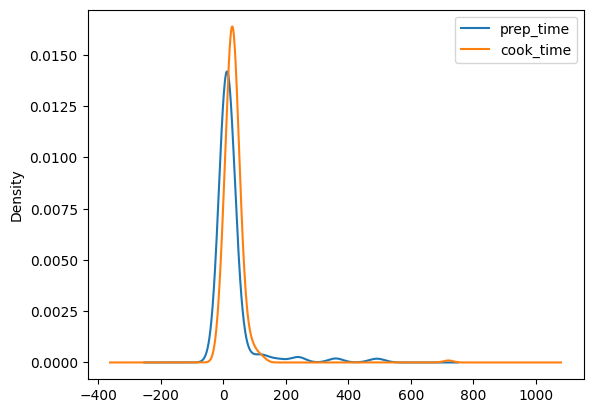

In [12]:
df.plot(kind='kde')

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

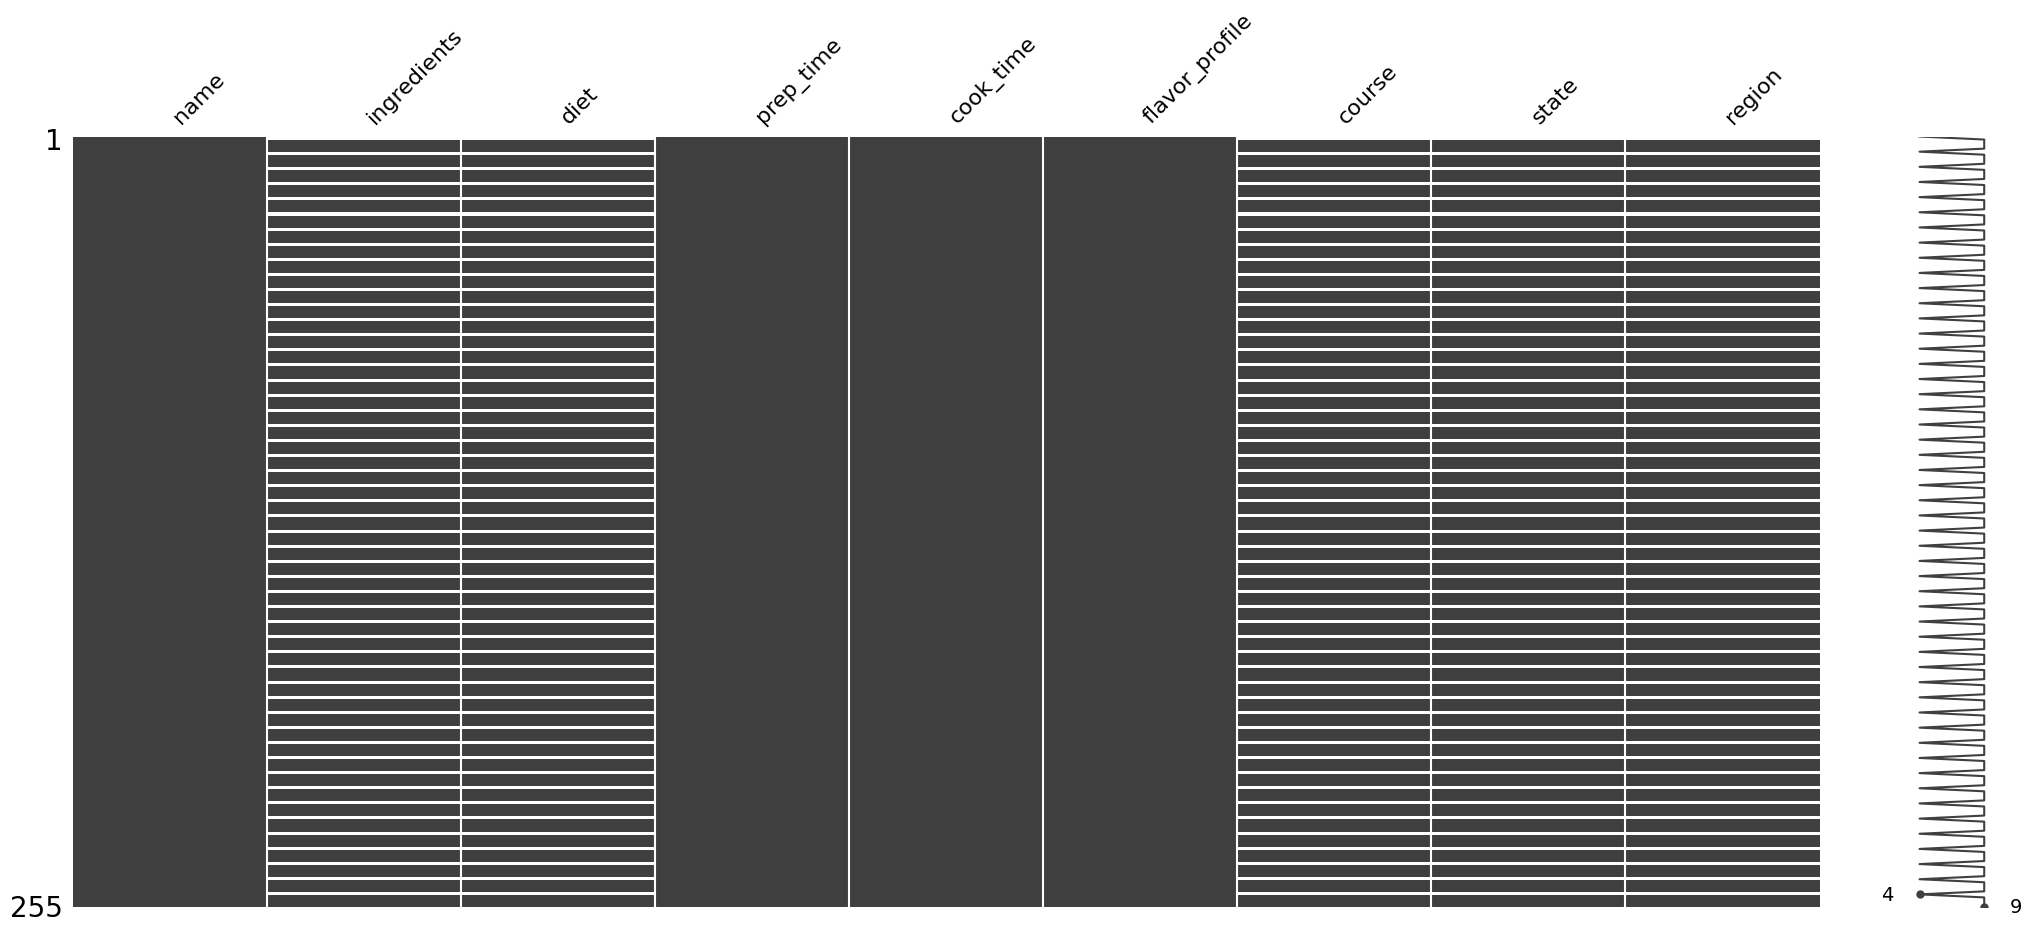

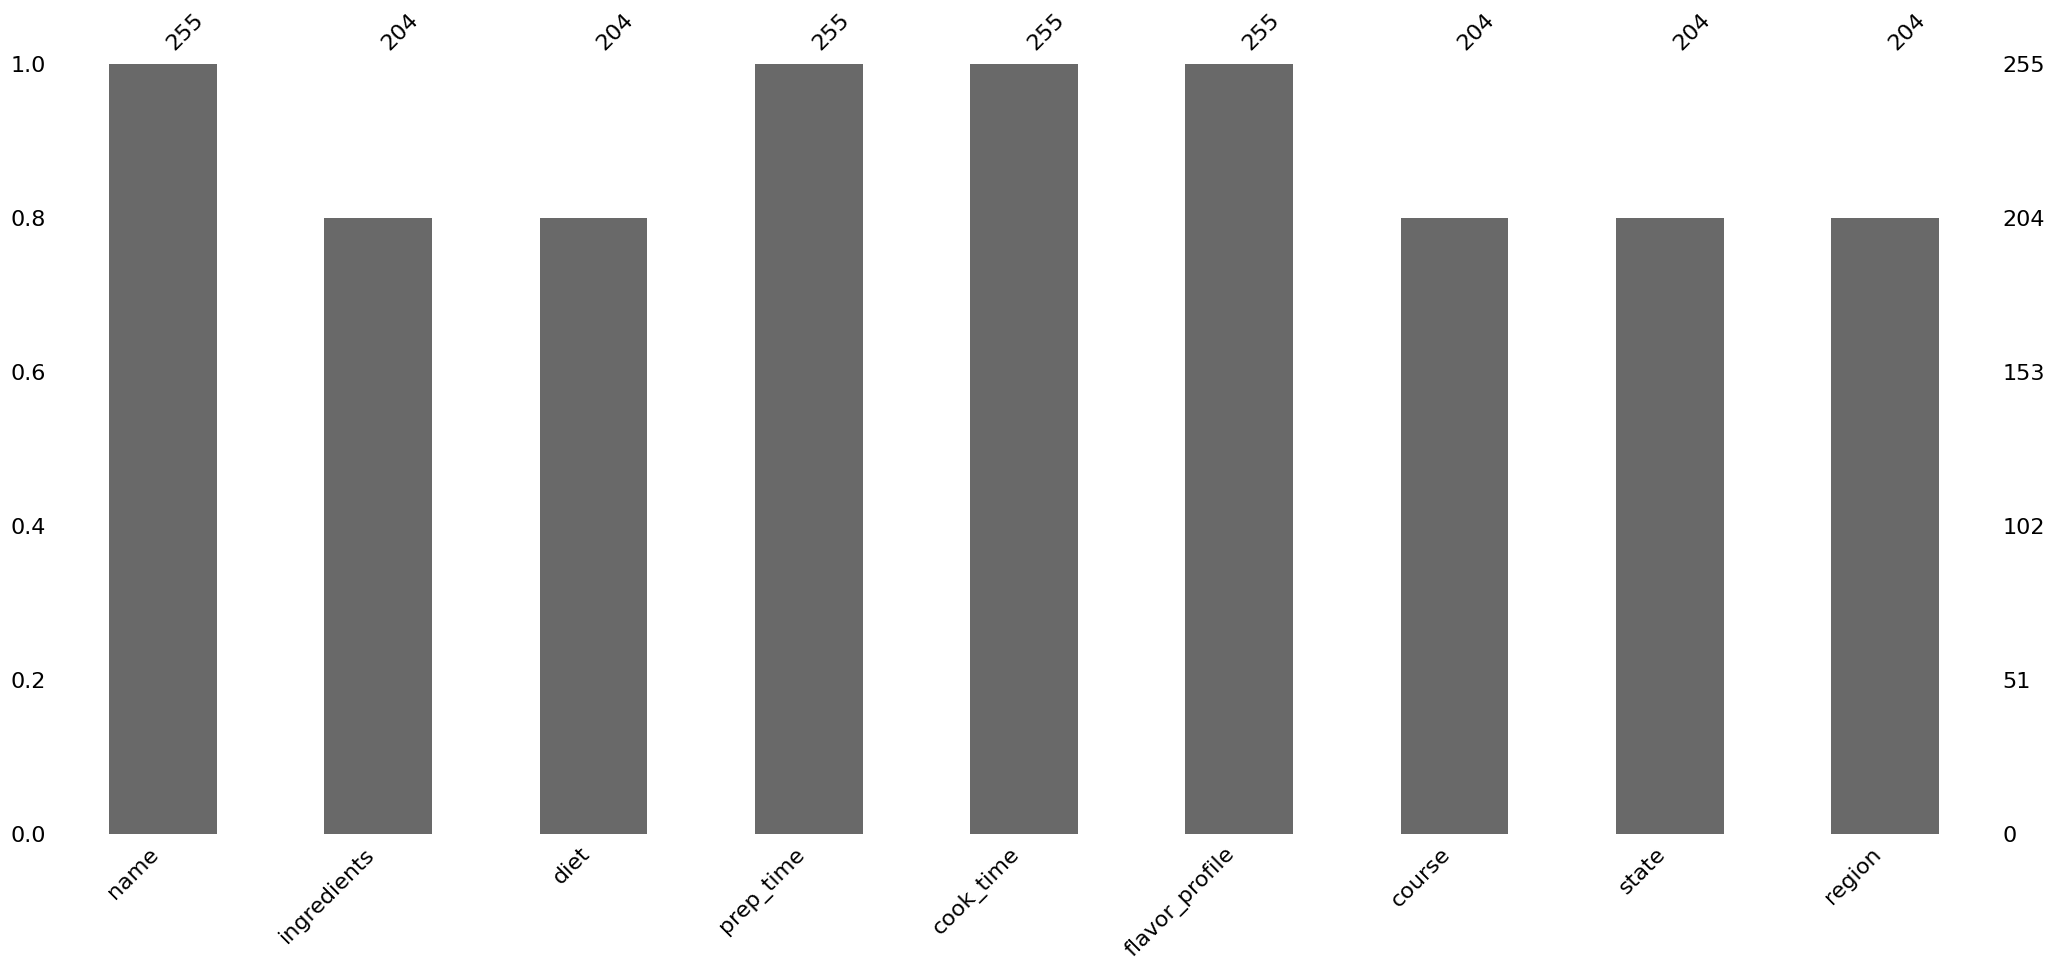

In [14]:
import missingno as msno # type: ignore

msno.matrix(df)
plt.show()


msno.bar(df)
plt.show()

In [15]:
impute = SimpleImputer()

In [16]:
df.columns

Index(['name', 'ingredients', 'diet', 'prep_time', 'cook_time',
       'flavor_profile', 'course', 'state', 'region'],
      dtype='object')

In [17]:
x = df.drop('state',axis=1)
y = df['state']

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)

In [19]:
x_train

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,region
38,Bandar laddu,"Besan, jaggery, cardamom powder, ghee, cashews...",vegetarian,5,35,sweet,dessert,South
143,Kuzhambu,"Pearl onions, urad dal, drumsticks, tomato, cu...",vegetarian,5,30,spicy,main course,South
84,Daal puri,"Moong dal, garam masala powder, garlic, green ...",vegetarian,30,30,spicy,main course,East
55,Anarsa,NaN,NaN,10,50,sweet,NaN,NaN
219,Churma Ladoo,"Whole wheat flour, khus khus, sesame seeds, dr...",vegetarian,12,40,sweet,dessert,West
...,...,...,...,...,...,...,...,...
106,Palak paneer,"Cottage cheese, palak, cream, garam masala, bu...",vegetarian,20,40,spicy,main course,North
14,Phirni,"Rice, sugar, nuts",vegetarian,30,20,sweet,dessert,East
92,Kadhi pakoda,"Besan, garam masala powder, gram flour, ginger...",vegetarian,10,60,spicy,main course,North
179,Dahi vada,"Urad dal, bhuna chana, garam masala, dates, ta...",vegetarian,30,30,-1,snack,West


In [20]:
x_test

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,region
190,Keri no ras,NaN,NaN,10,10,sour,NaN,NaN
6,Jalebi,"Maida, corn flour, baking soda, vinegar, curd,...",vegetarian,10,50,sweet,dessert,North
79,Chicken razala,"Chicken, dahi, sesame seeds, garam masala powd...",non vegetarian,10,35,spicy,main course,East
205,Namakpara,NaN,NaN,10,35,spicy,NaN,NaN
117,Samosa,"Potatoes, green peas, garam masala, ginger, dough",vegetarian,30,30,spicy,snack,-1
185,Ghooghra,NaN,NaN,-1,-1,spicy,NaN,NaN
201,Puri Bhaji,"Aloo, urad dal, mustard, ginger, curry leaves",vegetarian,10,30,spicy,main course,West
167,Kolim Jawla,"Baingan, fish, coconut oil, fresh coconut, ginger",non vegetarian,-1,-1,spicy,main course,West
9,Kheer,"Milk, rice, sugar, dried fruits",vegetarian,10,40,sweet,dessert,-1
30,Pantua,NaN,NaN,45,45,sweet,NaN,NaN


In [21]:
y_train

38     Andhra Pradesh
143        Tamil Nadu
84        West Bengal
55                NaN
219         Rajasthan
            ...      
106            Punjab
14             Odisha
92            Haryana
179       Maharashtra
102            Punjab
Name: state, Length: 204, dtype: object

In [22]:
y_test

190                NaN
6        Uttar Pradesh
79         West Bengal
205                NaN
117                 -1
185                NaN
201        Maharashtra
167        Maharashtra
9                   -1
30                 NaN
180                NaN
221              Assam
229            Manipur
216            Gujarat
136         Tamil Nadu
68              Punjab
198            Gujarat
15                 NaN
96                  -1
24              Odisha
234              Assam
19         Maharashtra
120                NaN
152         Tamil Nadu
33         West Bengal
124     Andhra Pradesh
252    Jammu & Kashmir
243        West Bengal
10                 NaN
164                 -1
184            Gujarat
97       Uttar Pradesh
148             Kerala
209            Gujarat
222              Assam
25                 NaN
86              Punjab
18       Uttar Pradesh
75                 NaN
137             Kerala
195                NaN
176            Gujarat
238              Assam
181        

In [23]:
df.columns

Index(['name', 'ingredients', 'diet', 'prep_time', 'cook_time',
       'flavor_profile', 'course', 'state', 'region'],
      dtype='object')

In [24]:
numerical = ['prep_time','cook_time']
categorical = ['ingredients','diet','flavor_profile','course','region','name']

In [25]:
numerical_impute = Pipeline([
    ('impute',SimpleImputer(strategy='mean')),
    ('scale',StandardScaler())
])

In [26]:
categorical_impute = Pipeline([
    ('char',SimpleImputer(strategy='most_frequent')),
    ('one',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [39]:
processor = ColumnTransformer([
    ('num',numerical_impute,numerical),
    ('cate',categorical_impute,categorical)
    
]
)

In [ ]:
from sklearn.linear_model import L

In [40]:
model_pipeline = Pipeline([
    ('proces',processor),
    ('model',LinearRegression())
])

In [42]:
model_pipeline.fit(x_train,y_train)

ValueError: A given column is not a column of the dataframe